### Building Chatbot with Multiple Tools Using LangGraph

#### AIM
create a chatbot with tool capabilities from arxiv, wikipedia search and some function

In [ ]:
from dotenv import load_dotenv
load_dotenv()
import os
os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVIY_API_KEY")

In [30]:
from langchain.chat_models import init_chat_model

model = init_chat_model(model = "groq:qwen/qwen3-32b")

In [49]:
import arxiv
from langchain.tools import tool

@tool
def arxiv_search(query: str, max_results: int = 2):
    """Search for academic papers on arXiv. Use this for research papers, scientific articles, and academic publications."""
    try:
        # Create search with specific criteria
        search = arxiv.Search(
            query=query,
            max_results=max_results,
            sort_by=arxiv.SortCriterion.Relevance,
            sort_order=arxiv.SortOrder.Descending
        )
        
        results = []
        # Use the search directly
        for paper in search.results():
            results.append({
                "title": paper.title,
                "summary": paper.summary[:500],
                "id": paper.entry_id,
                "published": paper.published.strftime("%Y-%m-%d"),
                "authors": ", ".join([a.name for a in paper.authors[:3]])
            })
        
        if not results:
            return f"No papers found for '{query}'"
        
        # Format for better readability (return a string!)
        output = []
        for r in results:
            output.append(
                f"📄 {r['title']}\n"
                f"👤 {r['authors']}\n"
                f"📅 {r['published']}\n"
                f"📝 {r['summary'][:200]}...\n"
                f"🔗 {r['id']}\n"
            )
        
        return "\n".join(output)
        
    except Exception as e:
        return f"Error searching arXiv: {str(e)}"


In [50]:
import wikipedia
from langchain.tools import tool

@tool
def wiki_search(query: str):
    """Search from wikipedia for general knowledge and information."""
    try:
        page = wikipedia.page(query, auto_suggest=False)
        return page.summary[:250]  # ✅ Returns a string - good!
    except wikipedia.exceptions.DisambiguationError as e:
        return f"Disambiguation: {e.options[:5]}"  # ✅ Returns a string
    except wikipedia.exceptions.PageError:
        return "No page found."  # ✅ Returns a string
    except Exception as e:
        return f"Error searching Wikipedia: {str(e)}"


In [27]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults(
    max_results=2,
    search_depth="advanced",
    include_answer=True,
    include_raw_content=False,
    include_images=False,
)

In [28]:
tavily.invoke("provide me the recent ai news june 30 2026")

[{'title': 'AI News Today June 30 2026: 15 Biggest Stories',
  'url': 'https://www.buildfastwithai.com/blogs/ai-news-today-june-30-2026',
  'content': "As of June 30, 2026: Claude Opus 4.8 and Sonnet 4.6 from Anthropic are fully available via API and subscriptions. GPT-5.5 from OpenAI is fully available. Gemini 2.5 Pro with Deep Think is available via Gemini API, AI Studio, and Vertex AI. GPT-5.5-Cyber is restricted to vetted Trusted Access for Cyber partners. GPT-5.6 Sol, Terra, and Luna are restricted to approximately 20 government-vetted partner organizations. Claude Fable 5 and Mythos 5 are suspended for general users; Mythos 5 is accessible to critical infrastructure defenders under the Lutnick Commerce letter. Gemini 3.5 Pro is in limited Vertex AI enterprise preview. GLM-5.2 from Zhipu AI is publicly available via the Z.ai API and Cloudflare Workers AI. Grok 5 is still in training. [...] Qualcomm confirmed on June 25, 2026 the acquisition of Modular, an AI infrastructure startup

In [ ]:
## combine my all tools in the list
tools = [arxiv_search, wiki_search, tavily]

In [31]:
model_with_tools = model.bind_tools(tools)

In [ ]:
from pprint import pprint
from langchain_core.messages import HumanMessage, AIMessage
model_with_tools.invoke([HumanMessage(content = "Search the intenet and tell the most upvotted news in the domain Artificial Intelligence")])

[{'name': 'tavily_search_results_json',
  'args': {'query': 'top upvoted Artificial Intelligence news'},
  'id': 'yns0ncb3j',
  'type': 'tool_call'}]

In [36]:
### State schema
from typing_extensions import TypedDict, Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

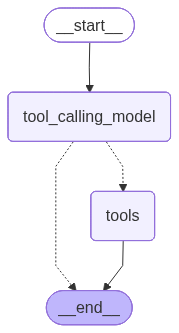

In [43]:
### Entire Chatbot with Langgraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

## node definition
def tool_calling_model(state:State):
    return {"messages": model_with_tools.invoke(state['messages'])}

## Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_model", tool_calling_model)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_model")
builder.add_conditional_edges(
    "tool_calling_model",
    tools_condition
)
builder.add_edge("tools", END)

## display the graph
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [51]:
messages = graph.invoke({"messages": HumanMessage(content = "Attetnion is al you need")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Attetnion is al you need
================================== Ai Message ==================================

The phrase "Attention is all you need" refers to the groundbreaking research paper that introduced the Transformer architecture. This paper, published in 2017, revolutionized natural language processing (NLP) by demonstrating that self-attention mechanisms could outperform traditional recurrent neural networks (RNNs) and convolutional neural networks (CNNs) in tasks like machine translation.

The Transformer's key innovation was its use of **self-attention** to process input sequences in parallel, enabling faster training and better handling of long-range dependencies in text. This architecture became the foundation for many state-of-the-art models, including BERT, GPT, and others.

Would you like a link to the original paper on arXiv?


In [52]:
messages = graph.invoke({"messages": HumanMessage(content = "Provide me the top 10 AI news to the date 30 june 2026")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 AI news to the date 30 june 2026
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (s1f0yardk)
 Call ID: s1f0yardk
  Args:
    query: top 10 AI news June 30 2026
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News Today June 30 2026: 15 Biggest Stories", "url": "https://www.buildfastwithai.com/blogs/ai-news-today-june-30-2026", "content": "9. GitHub Copilot Metered Billing Month-End Fallout: Bills Jump 10x to 50x for Power Users\n   10. Why the End of Flat-Rate AI Is the Biggest Structural Shift in Developer Tools Since 2022\n   11. Google Loses Its Sixth AI Researcher: Denny Zhou Already at Meta Superintelligence Lab\n   12. The June 2026 Model Race That Did Not Happen: GPT-5.6 Gated, Grok 5 Still Training\n   13. Amazon Custom Si

In [53]:
messages = graph.invoke({"messages": HumanMessage(content = "What is Machine Learning?")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is Machine Learning?
================================== Ai Message ==================================
Tool Calls:
  wiki_search (2wb4erq00)
 Call ID: 2wb4erq00
  Args:
    query: Machine Learning
================================= Tool Message =================================
Name: wiki_search

Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programme
